In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

year = 2019

final_df = pd.read_csv("../../data/07_portfolios_metadata/complete_metadata.csv")
cols_to_keep = ["Ticker", "Country", "Sector", "Industry", "portfolio"]
final_df_cols = cols_to_keep + [x for x in final_df.columns if str(year) in x]
final_df = final_df[final_df["year"]==year][final_df_cols]

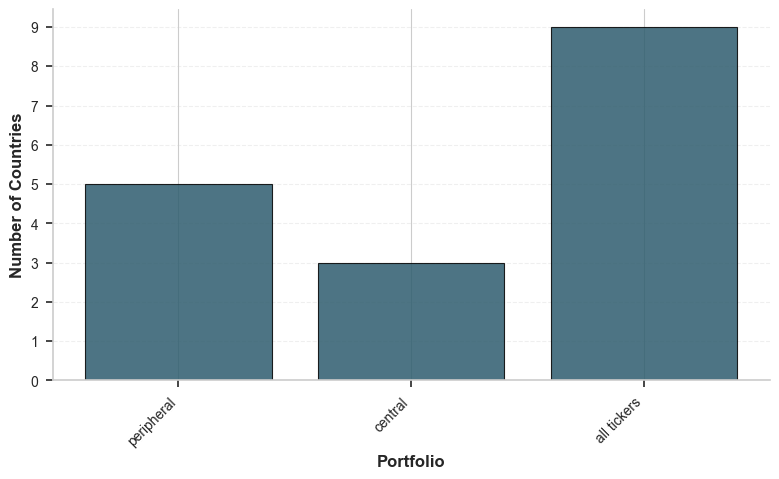

In [64]:
# Set publication-quality style
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4)

# Prepare data
portfolios = ["peripheral", "central"]
temp = pd.DataFrame(columns=["n_countries"], index=portfolios)

for i in range(len(portfolios)):
    temp.loc[portfolios[i]] = final_df[final_df["portfolio"]==portfolios[i]]["Country"].nunique()
temp.loc["all tickers"] = final_df["Country"].nunique()

plot_df = temp.reset_index().rename(columns={"index": "portfolio"})

# Create figure with publication dimensions
fig, ax = plt.subplots(figsize=(8, 5))

# Create bar plot with professional styling
bars = ax.bar(
    range(len(plot_df)),
    plot_df["n_countries"],
    color='#2E5C6E',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.85
)

# Customize axes
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df["portfolio"], rotation=45, ha='right')
ax.set_xlabel("Portfolio", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of Countries", fontsize=12, fontweight='bold')

# Add gridlines for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Improve tick parameters
ax.tick_params(axis='both', which='major', labelsize=10, width=1.2)

# Set integer ticks on y-axis
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Tighten layout
plt.tight_layout()

# Save with high quality
out_dir = "../../figures"
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"country_barplot_{year}.png"
fig.savefig(
    out_path / filename, 
    dpi=300, 
    bbox_inches="tight",
    facecolor='white',
    edgecolor='none'
)

# Also save as vector format for publications
fig.savefig(
    out_path / f"country_barplot_{year}.pdf", 
    bbox_inches="tight",
    facecolor='white'
)

plt.show()

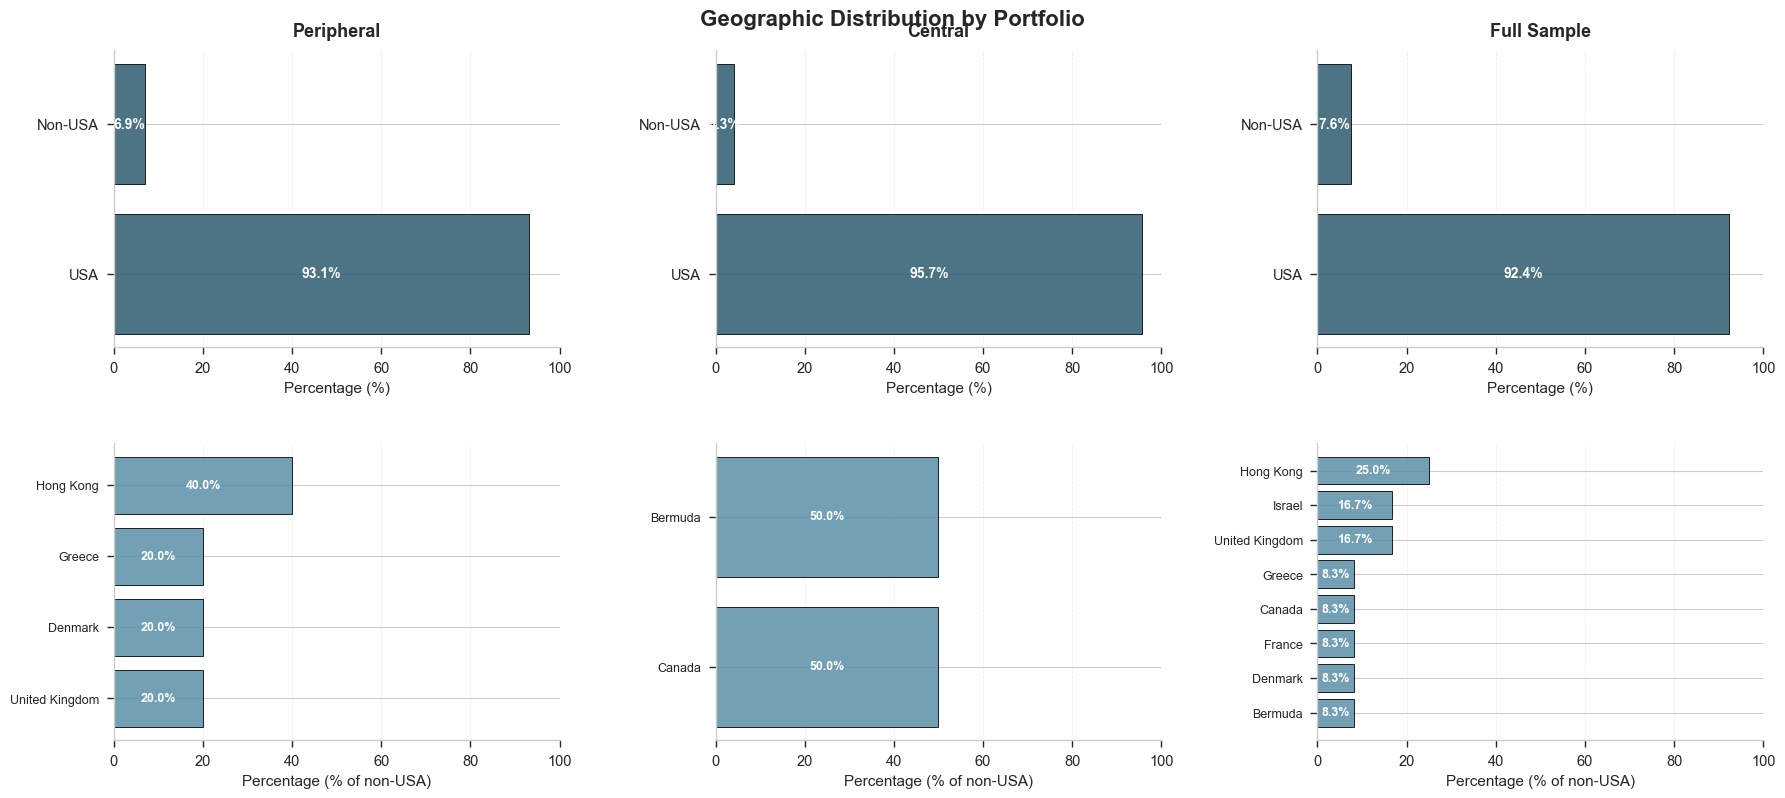

In [65]:
# Set publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

portfolios = ["peripheral", "central"]
plots = list(portfolios) + ["Full sample"]

n_cols = 3
n_rows = int(np.ceil(len(plots) / n_cols)) * 2

# Create figure with better spacing
fig, axes = plt.subplots(
    n_rows, n_cols, 
    figsize=(18, 4 * n_rows)
)
axes = axes.reshape(n_rows, n_cols)

# Define professional color palette
color_usa = '#2E5C6E'
color_detail = '#5A8FA8'

for i, port in enumerate(plots):

    row_block = (i // n_cols) * 2
    col = i % n_cols

    ax_top = axes[row_block, col]
    ax_bottom = axes[row_block + 1, col]

    if port == "Full sample":
        data = final_df.copy()
        title = "Full Sample"
    else:
        data = final_df[final_df["portfolio"] == port].copy()
        title = port.capitalize()

    # ---------- TOP: USA vs Non-USA ----------
    usa_pct = (data["Country"] == "USA").mean() * 100
    non_usa_pct = 100 - usa_pct

    summary = pd.DataFrame({
        "Category": ["USA", "Non-USA"],
        "Percentage": [usa_pct, non_usa_pct]
    })

    bars_top = ax_top.barh(
        summary["Category"],
        summary["Percentage"],
        color=color_usa,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85
    )

    # Add percentage labels on bars
    for j, (cat, pct) in enumerate(zip(summary["Category"], summary["Percentage"])):
        ax_top.text(
            pct / 2, j, f'{pct:.1f}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='white'
        )

    ax_top.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax_top.set_xlabel("Percentage (%)", fontsize=11)
    ax_top.set_ylabel("")
    ax_top.set_xlim(0, 100)
    
    # Clean up top panel
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_top.spines['left'].set_linewidth(1.0)
    ax_top.spines['bottom'].set_linewidth(1.0)
    ax_top.grid(axis='x', linestyle='--', alpha=0.3, linewidth=0.6)
    ax_top.set_axisbelow(True)

    # ---------- BOTTOM: Non-USA breakdown (sums to 100%) ----------
    non_usa_detail = (
        data.loc[data["Country"] != "USA", "Country"]
        .value_counts(normalize=True)
        .mul(100)  # Convert to percentage (sums to 100%)
        .reset_index()
    )
    non_usa_detail.columns = ["Category", "Percentage"]
    
    # Sort by percentage for better visualization
    non_usa_detail = non_usa_detail.sort_values("Percentage", ascending=True)

    if len(non_usa_detail) > 0:
        bars_bottom = ax_bottom.barh(
            non_usa_detail["Category"],
            non_usa_detail["Percentage"],
            color=color_detail,
            edgecolor='black',
            linewidth=0.7,
            alpha=0.85
        )

        # Add percentage labels only if bar is wide enough
        for j, (cat, pct) in enumerate(zip(non_usa_detail["Category"], non_usa_detail["Percentage"])):
            if pct > 3:  # Only show label if bar is wide enough
                ax_bottom.text(
                    pct / 2, j, f'{pct:.1f}%',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white'
                )

        ax_bottom.set_xlabel("Percentage (% of non-USA)", fontsize=11)
        ax_bottom.set_ylabel("", fontsize=11)
        ax_bottom.set_xlim(0, 100)
        
        # Clean up bottom panel
        ax_bottom.spines['top'].set_visible(False)
        ax_bottom.spines['right'].set_visible(False)
        ax_bottom.spines['left'].set_linewidth(1.0)
        ax_bottom.spines['bottom'].set_linewidth(1.0)
        ax_bottom.grid(axis='x', linestyle='--', alpha=0.3, linewidth=0.6)
        ax_bottom.set_axisbelow(True)
        ax_bottom.tick_params(axis='y', labelsize=9)
    else:
        ax_bottom.text(
            0.5, 0.5, 'No non-USA data',
            ha='center', va='center',
            transform=ax_bottom.transAxes,
            fontsize=11, style='italic', color='gray'
        )
        ax_bottom.set_xlim(0, 100)

# Turn off empty axes
for ax in axes.flatten():
    if not ax.has_data():
        ax.axis("off")

# Adjust spacing between subplots
plt.tight_layout(h_pad=3.0, w_pad=2.5)

# Add overall title
fig.suptitle(
    'Geographic Distribution by Portfolio',
    fontsize=16,
    fontweight='bold',
    y=0.995
)

# Save outputs
out_dir = "../../figures"
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

# Save high-quality PNG
filename = f"country_barplot_det_{year}.png"
fig.savefig(
    out_path / filename,
    dpi=300,
    bbox_inches="tight",
    facecolor='white',
    edgecolor='none'
)

# Save vector format for publications
fig.savefig(
    out_path / f"country_barplot_det_{year}.pdf",
    bbox_inches="tight",
    facecolor='white'
)

plt.show()

## Sector

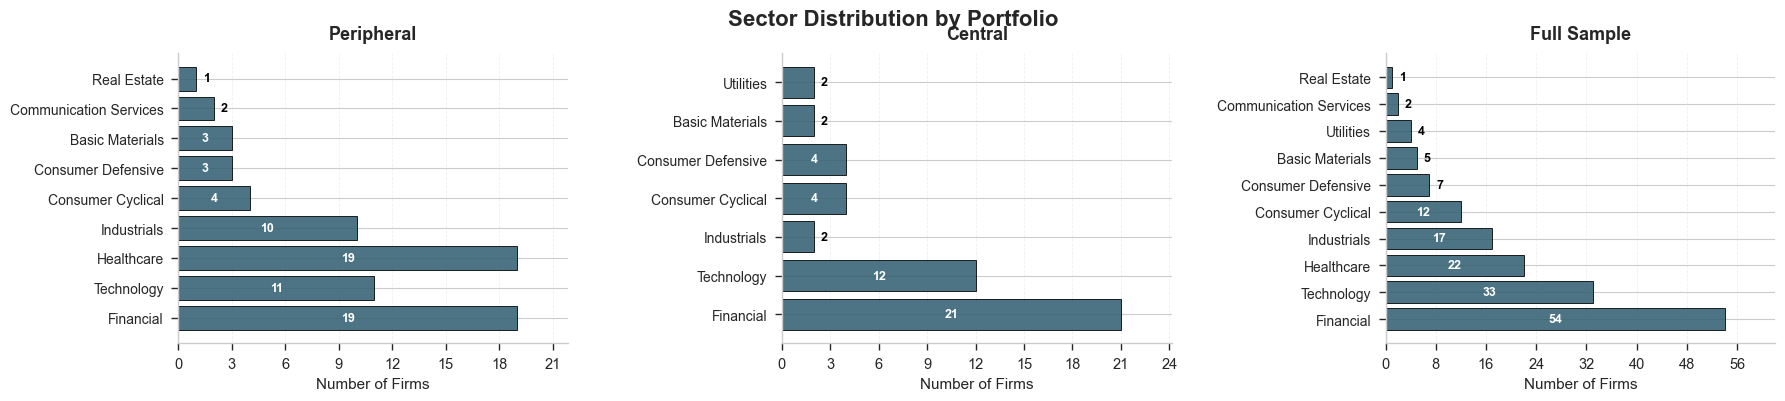

In [66]:
# Set publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

portfolios = ["peripheral", "central"]
plots = list(portfolios) + ["Full sample"]

n_cols = 3
n_rows = int(np.ceil(len(plots) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

# Define professional color
color_main = '#2E5C6E'

# Get global sector order based on full sample
sector_order = final_df["Sector"].value_counts().index

for ax, port in zip(axes, plots):
    if port == "Full sample":
        data = final_df
        title = "Full Sample"
    else:
        data = final_df[final_df["portfolio"] == port]
        title = port.capitalize()

    # Count sectors
    sector_counts = data["Sector"].value_counts()
    plot_data = pd.DataFrame({
        'Sector': sector_counts.index,
        'Count': sector_counts.values
    })
    
    # Sort by global order
    plot_data['Sector'] = pd.Categorical(
        plot_data['Sector'], 
        categories=sector_order, 
        ordered=True
    )
    plot_data = plot_data.sort_values('Sector')
    
    # Create horizontal bar plot
    bars = ax.barh(
        range(len(plot_data)),
        plot_data['Count'],
        color=color_main,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85
    )
    
    # Set y-axis labels
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels(plot_data['Sector'], fontsize=10)
    
    # Add count labels on bars
    for i, (sector, count) in enumerate(zip(plot_data['Sector'], plot_data['Count'])):
        # Place label at the end of bar or inside if bar is long enough
        if count > plot_data['Count'].max() * 0.15:
            ax.text(
                count / 2, i, f'{count}',
                ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white'
            )
        else:
            ax.text(
                count + plot_data['Count'].max() * 0.02, i, f'{count}',
                ha='left', va='center',
                fontsize=9, fontweight='bold',
                color='black'
            )
    
    # Set title and labels
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Number of Firms", fontsize=11)
    ax.set_ylabel("")
    
    # Clean up axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.grid(axis='x', linestyle='--', alpha=0.3, linewidth=0.6)
    ax.set_axisbelow(True)
    
    # Set x-axis to start at 0
    ax.set_xlim(0, plot_data['Count'].max() * 1.15)
    
    # Integer ticks on x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Turn off empty axes
for ax in axes[len(plots):]:
    ax.axis("off")

# Adjust spacing
plt.tight_layout(h_pad=3.0, w_pad=2.5)

# Add overall title
fig.suptitle(
    'Sector Distribution by Portfolio',
    fontsize=16,
    fontweight='bold',
    y=0.998
)

# Save outputs
out_dir = "../../figures"
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

# Save high-quality PNG
filename = f"sector_barplot_{year}.png"
fig.savefig(
    out_path / filename,
    dpi=300,
    bbox_inches="tight",
    facecolor='white',
    edgecolor='none'
)

# Save vector format for publications
fig.savefig(
    out_path / f"sector_barplot_{year}.pdf",
    bbox_inches="tight",
    facecolor='white'
)

plt.show()

## Industry

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\1627612752.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x*100:.0f}%' for x in vals])
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\1627612752.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{x*100:.0f}%' for x in vals])


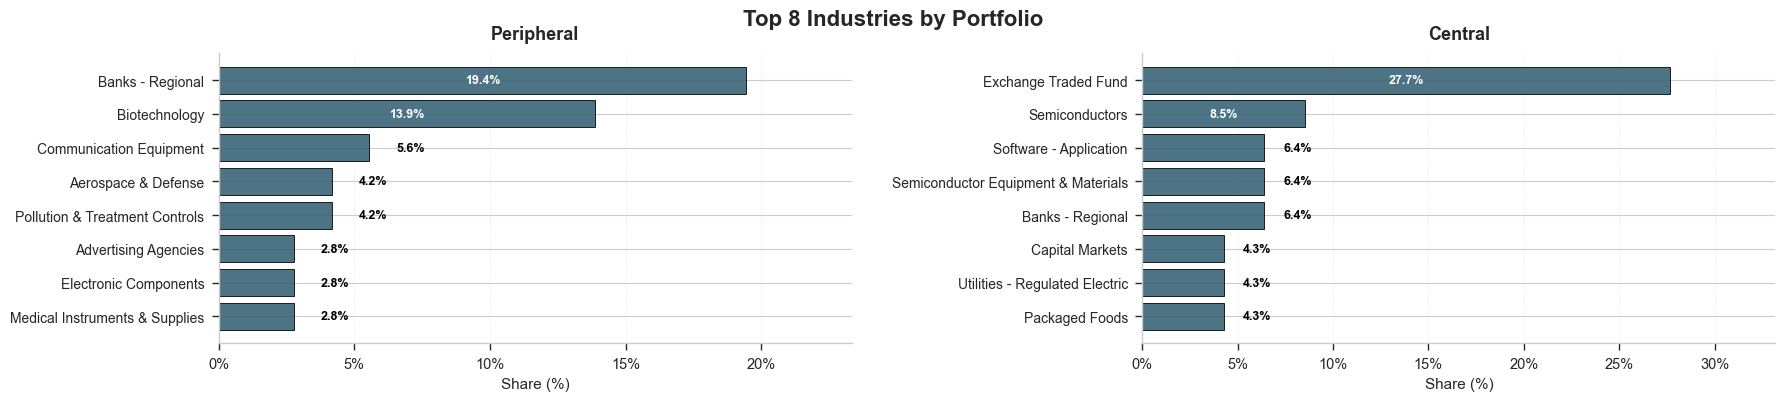

In [67]:
# Set publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

top_n = 8
portfolios = ["peripheral", "central"]

n_cols = 2
n_rows = int(np.ceil(len(portfolios) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

# Define professional color
color_main = '#2E5C6E'

for ax, port in zip(axes, portfolios):
    data = (
        final_df[final_df["portfolio"] == port]["Industry"]
        .value_counts(normalize=True)
        .head(top_n)
        .reset_index()
    )
    data.columns = ["Industry", "share"]
    
    # Sort by share for better visualization
    data = data.sort_values("share", ascending=True)
    
    # Create horizontal bar plot
    bars = ax.barh(
        range(len(data)),
        data["share"],
        color=color_main,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85
    )
    
    # Set y-axis labels
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data["Industry"], fontsize=10)
    
    # Add percentage labels on bars
    for i, (industry, share) in enumerate(zip(data["Industry"], data["share"])):
        pct_label = f'{share * 100:.1f}%'
        
        # Place label inside bar if wide enough, otherwise outside
        if share > 0.08:  # If bar is wider than 8%
            ax.text(
                share / 2, i, pct_label,
                ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white'
            )
        else:
            ax.text(
                share + 0.01, i, pct_label,
                ha='left', va='center',
                fontsize=9, fontweight='bold',
                color='black'
            )
    
    # Set title and labels
    ax.set_title(port.capitalize(), fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Share (%)", fontsize=11)
    ax.set_ylabel("")
    
    # Format x-axis as percentage
    ax.set_xlim(0, data["share"].max() * 1.2)
    
    # Convert x-axis to percentage labels
    vals = ax.get_xticks()
    ax.set_xticklabels([f'{x*100:.0f}%' for x in vals])
    
    # Clean up axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.grid(axis='x', linestyle='--', alpha=0.3, linewidth=0.6)
    ax.set_axisbelow(True)

# Turn off empty axes
for ax in axes[len(portfolios):]:
    ax.axis("off")

# Adjust spacing
plt.tight_layout(h_pad=3.0, w_pad=2.5)

# Add overall title
fig.suptitle(
    f'Top {top_n} Industries by Portfolio',
    fontsize=16,
    fontweight='bold',
    y=0.998
)

# Save outputs
out_dir = "../../figures"
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

# Save high-quality PNG
filename = f"industry_barplot_{year}.png"
fig.savefig(
    out_path / filename,
    dpi=300,
    bbox_inches="tight",
    facecolor='white',
    edgecolor='none'
)

# Save vector format for publications
fig.savefig(
    out_path / f"industry_barplot_{year}.pdf",
    bbox_inches="tight",
    facecolor='white'
)

plt.show()

## Função de boxplots

In [75]:
def plot_metric_boxplots(
    df,
    metric,
    portfolio_col="portfolio",
    log_scale=False,
    figsize=(15, 5),
    metric_name=None,
    showfliers=False,
    save=True,
    out_dir="../../figures",
    dpi=300
): 
    # Set publication-quality style
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("paper", font_scale=1.3)
    
    cut_col = metric + "_cut"
    metric_label = metric_name if metric_name else metric
    title_left = f"{metric_label} by Portfolios"
    title_right = f"{metric_label} by Quantile Cuts"
    
    # Professional font sizes
    TITLE_SIZE = 16
    LABEL_SIZE = 13
    TICK_SIZE = 11
    
    # Professional color palette
    box_color = '#2E5C6E'
    median_color = "#22125F"
    
    # Define portfolio order (peripheral first)
    portfolio_order = ['peripheral', 'mid', 'core']
    # Filter to only include portfolios that exist in the data
    available_portfolios = df[portfolio_col].dropna().unique()
    portfolio_order = [p for p in portfolio_order if p in available_portfolios]
    # Add any portfolios not in the predefined order
    portfolio_order += [p for p in available_portfolios if p not in portfolio_order]
    
    fig, ax = plt.subplots(1, 2, figsize=figsize)
    
    # Log scale
    y_label = metric_label
    if log_scale:
        ax[0].set_yscale("log")
        ax[1].set_yscale("log")
        y_label = f"{metric_label} (log scale)"
    
    # ==================== Left plot: By Portfolios ====================
    bp1 = ax[0].boxplot(
        [df[df[portfolio_col] == p][metric].dropna() for p in portfolio_order],
        labels=[p.capitalize() for p in portfolio_order],
        patch_artist=True,
        showfliers=showfliers,
        widths=0.6,
        medianprops=dict(color=median_color, linewidth=2.5),
        boxprops=dict(facecolor=box_color, edgecolor='black', linewidth=1.2, alpha=0.7),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
    )
    
    ax[0].set_title(title_left, fontsize=TITLE_SIZE, fontweight="bold", pad=15)
    ax[0].set_xlabel("Portfolio", fontsize=LABEL_SIZE, fontweight="bold")
    ax[0].set_ylabel(y_label, fontsize=LABEL_SIZE, fontweight="bold")
    ax[0].tick_params(axis="x", rotation=45, labelsize=TICK_SIZE, width=1.2)
    ax[0].tick_params(axis="y", labelsize=TICK_SIZE, width=1.2)
    
    # Clean up axes
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['left'].set_linewidth(1.2)
    ax[0].spines['bottom'].set_linewidth(1.2)
    ax[0].grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
    ax[0].set_axisbelow(True)
    
    # ==================== Right plot: By Quantile Cuts ====================
    quantile_data = [df[df[cut_col] == i][metric].dropna() for i in [1,2]]
    
    bp2 = ax[1].boxplot(
        quantile_data,
        labels=[str(i) for i in range(1, len(quantile_data) + 1)],
        patch_artist=True,
        showfliers=showfliers,
        widths=0.6,
        medianprops=dict(color=median_color, linewidth=2.5),
        boxprops=dict(facecolor=box_color, edgecolor='black', linewidth=1.2, alpha=0.7),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
    )
    
    ax[1].set_title(title_right, fontsize=TITLE_SIZE, fontweight="bold", pad=15)
    ax[1].set_xlabel("Quantile", fontsize=LABEL_SIZE, fontweight="bold")
    ax[1].set_ylabel(y_label, fontsize=LABEL_SIZE, fontweight="bold")
    ax[1].tick_params(axis="x", rotation=0, labelsize=TICK_SIZE, width=1.2)
    ax[1].tick_params(axis="y", labelsize=TICK_SIZE, width=1.2)
    
    # Clean up axes
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    ax[1].spines['left'].set_linewidth(1.2)
    ax[1].spines['bottom'].set_linewidth(1.2)
    ax[1].grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
    ax[1].set_axisbelow(True)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure
    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        
        # Save PNG
        filename = f"{metric}_boxplot_{year}.png"
        fig.savefig(
            out_path / filename,
            dpi=dpi,
            bbox_inches="tight",
            facecolor='white',
            edgecolor='none'
        )
        
        # Save PDF for publications
        fig.savefig(
            out_path / f"{metric}_boxplot_{year}.pdf",
            bbox_inches="tight",
            facecolor='white'
        )
    
    plt.show()

## Market Cap

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


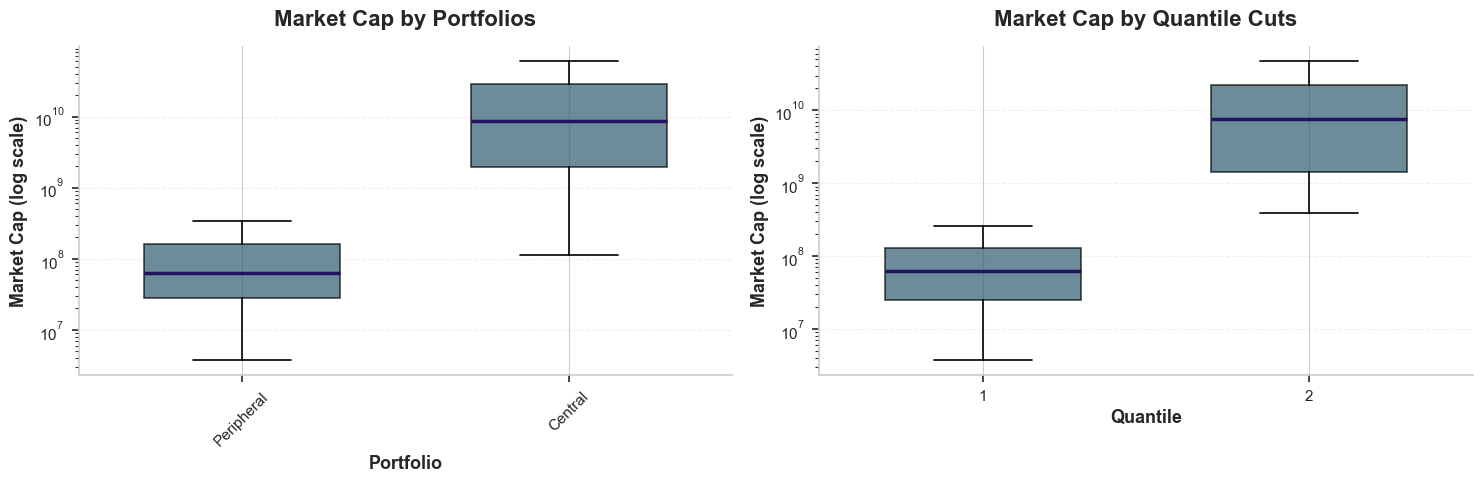

In [76]:
plot_metric_boxplots(
    df=final_df,
    metric=f"mcap_{year}",
    log_scale=True,
    metric_name="Market Cap"
)

## Price to Earnings

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


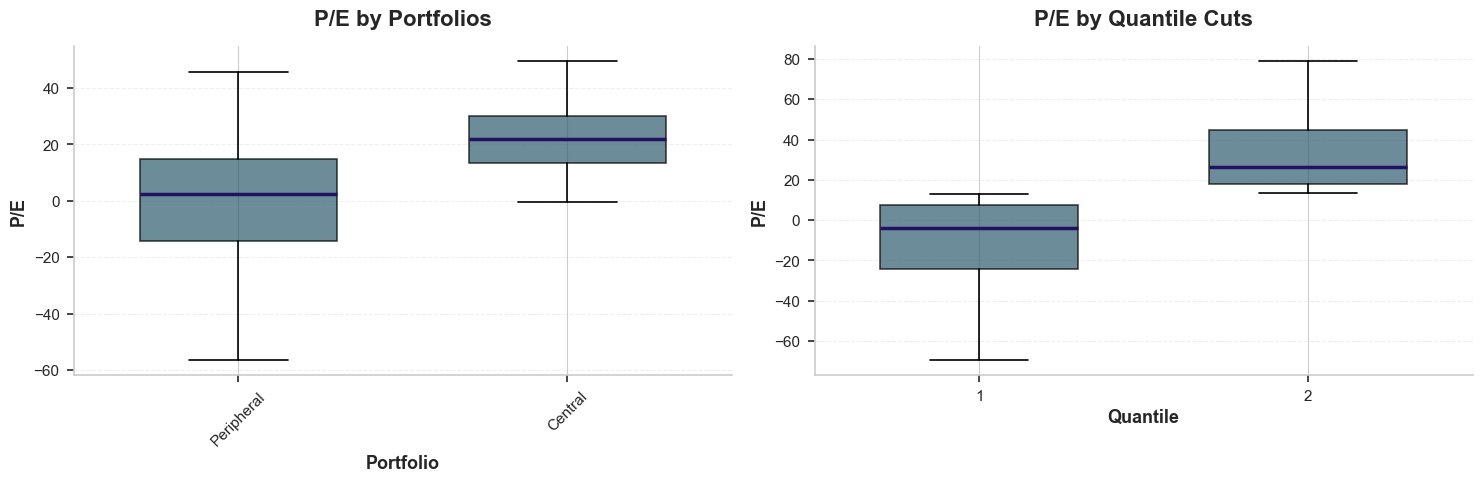

In [77]:
plot_metric_boxplots(
    df=final_df,
    metric=f"pe_{year}",
    log_scale=False,
    metric_name="P/E"
)

### Piotroski Score

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


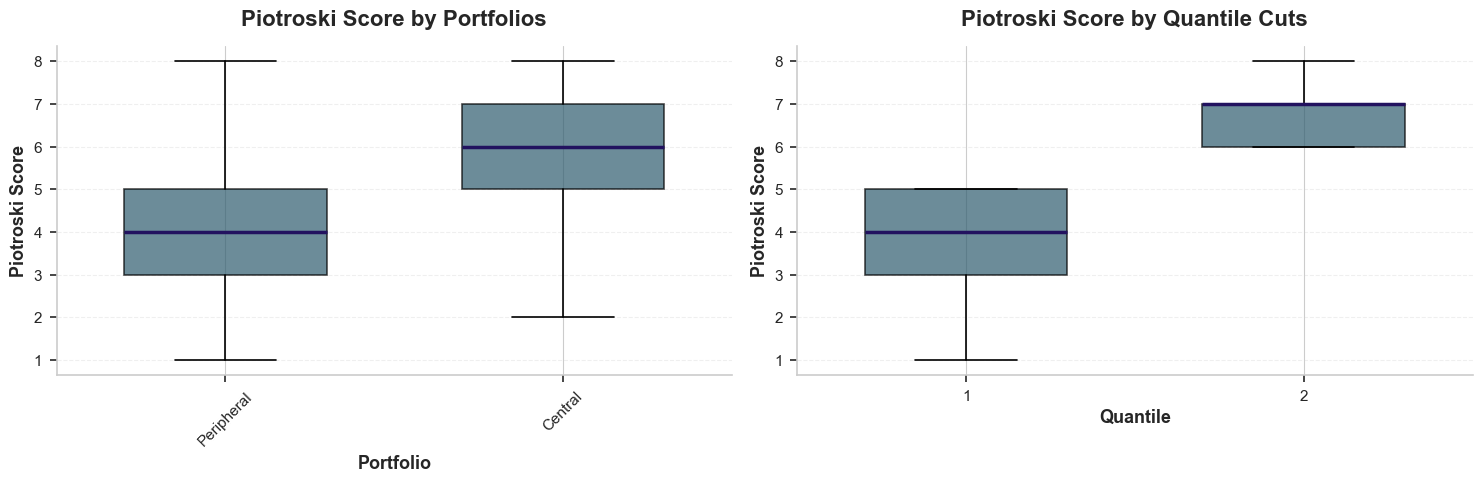

In [78]:
plot_metric_boxplots(
    df=final_df,
    metric=f"pscore_{year}",
    log_scale=False,
    metric_name="Piotroski Score"
)

### Altman Z Score

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


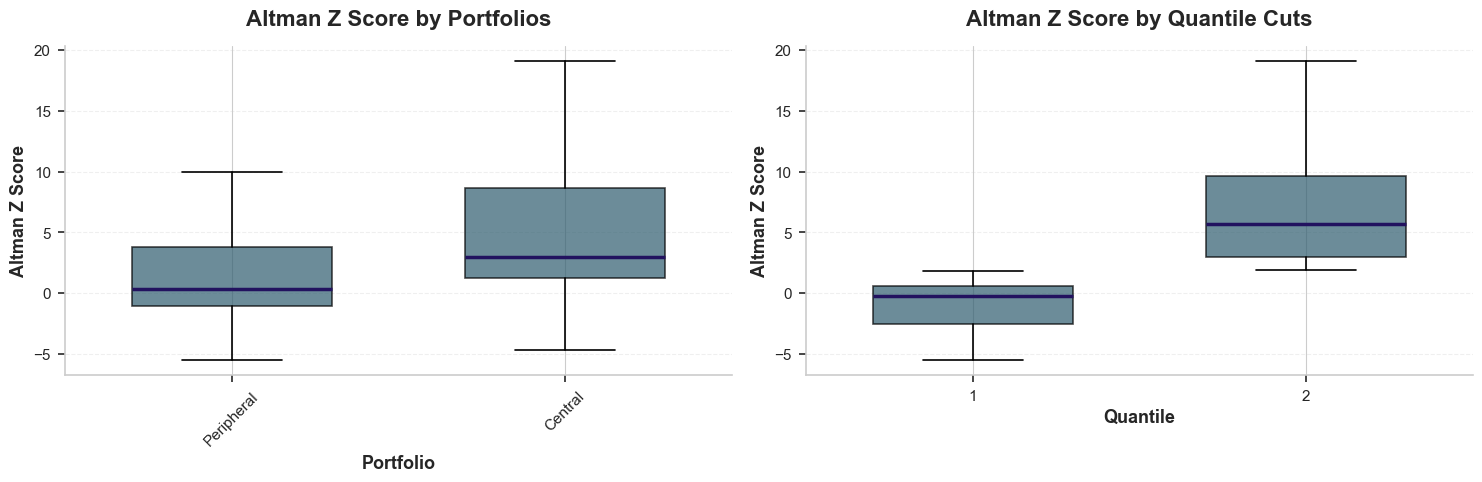

In [79]:
plot_metric_boxplots(
    df=final_df,
    metric=f"azscore_{year}",
    log_scale=False,
    metric_name="Altman Z Score"
)

### Free Cash Flow Yield

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


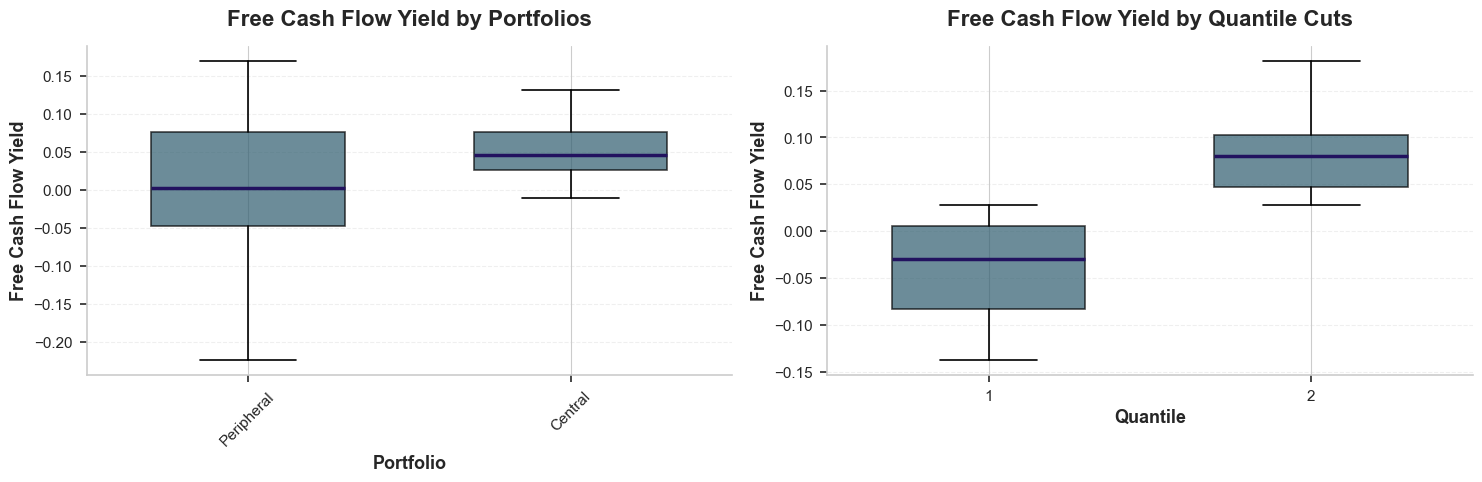

In [80]:
plot_metric_boxplots(
    df=final_df,
    metric=f"fcfyield_{year}",
    log_scale=False,
    metric_name="Free Cash Flow Yield"
)

### Return on Invested Capital

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


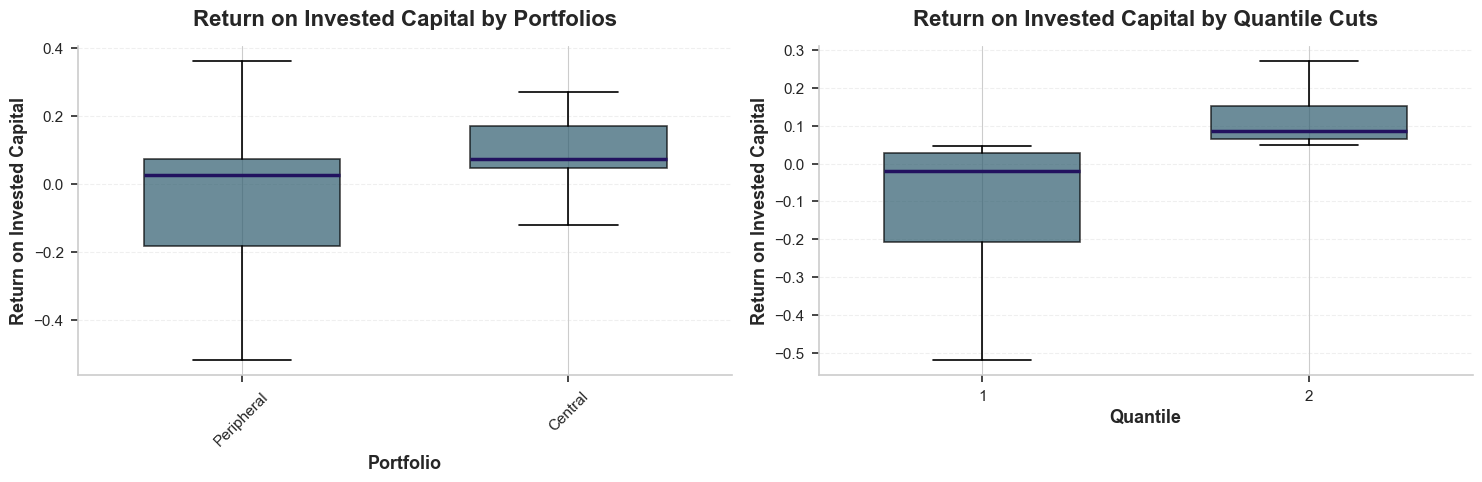

In [81]:
plot_metric_boxplots(
    df=final_df,
    metric=f"roic_{year}",
    log_scale=False,
    metric_name="Return on Invested Capital"
)

### Revenue Growth

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


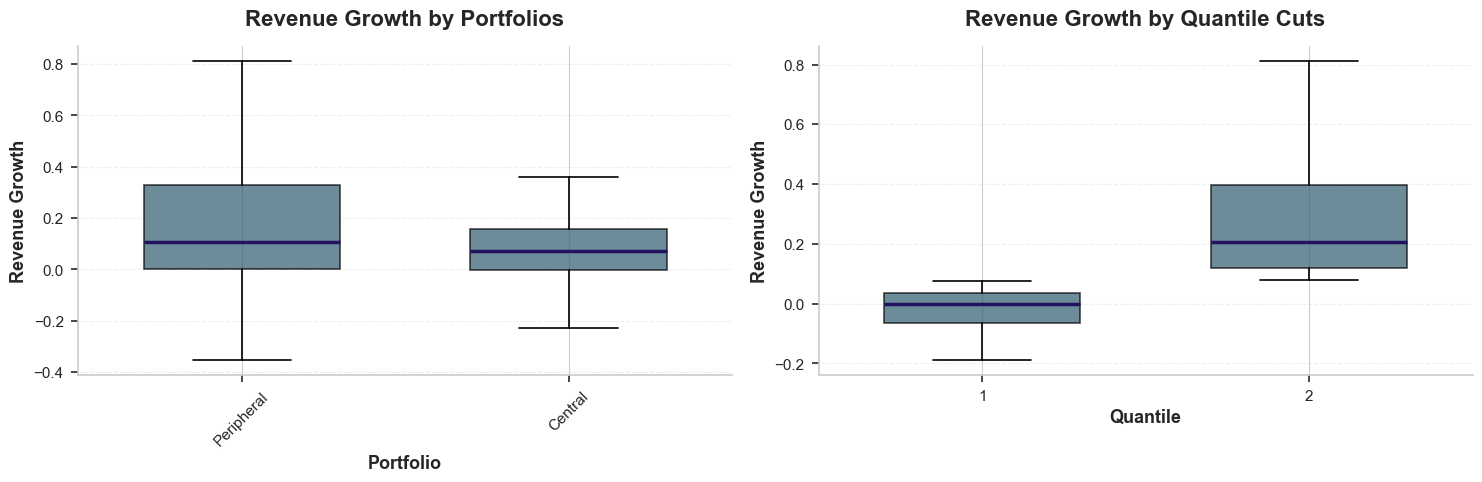

In [82]:
plot_metric_boxplots(
    df=final_df,
    metric=f"rg_{year}",
    log_scale=False,
    metric_name="Revenue Growth"
)

### Net Debt / EBITDA

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


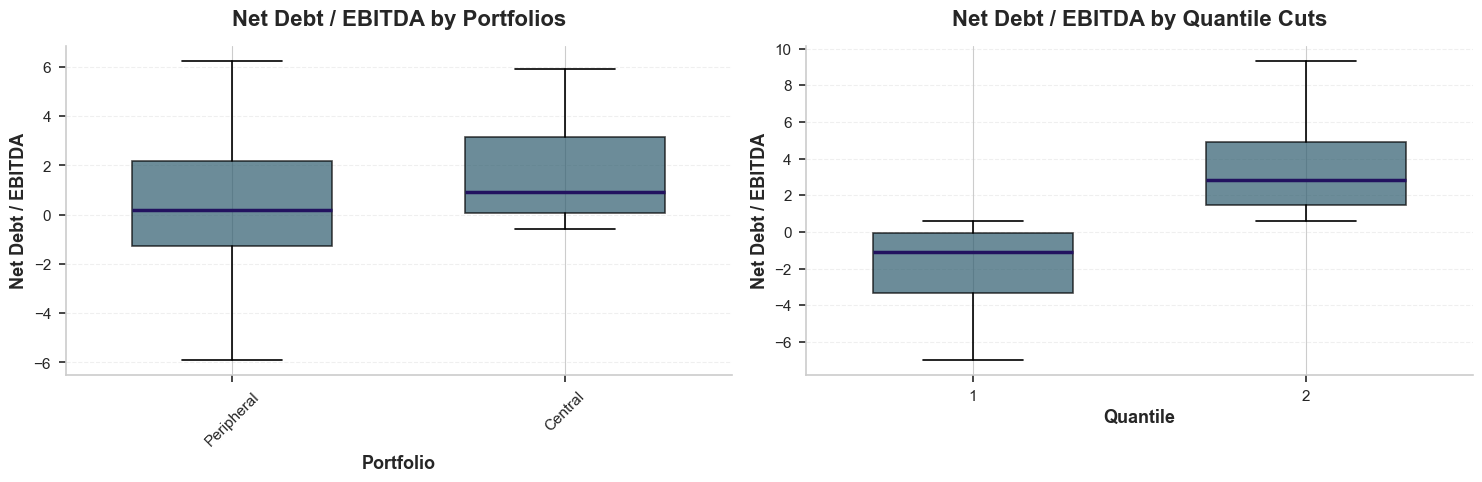

In [83]:
plot_metric_boxplots(
    df=final_df,
    metric=f"ndebitda_{year}",
    log_scale=False,
    metric_name="Net Debt / EBITDA"
)

### Gross Profit Margin

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


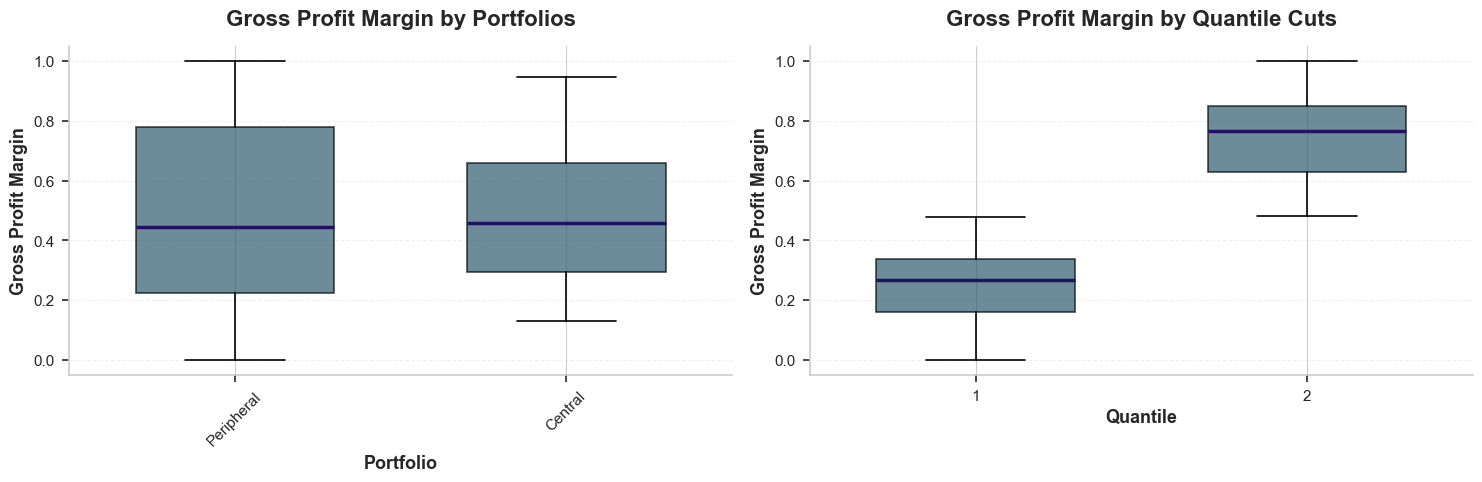

In [84]:
plot_metric_boxplots(
    df=final_df,
    metric=f"gpm_{year}",
    log_scale=False,
    metric_name="Gross Profit Margin"
)

### EPS Diluted Growth

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


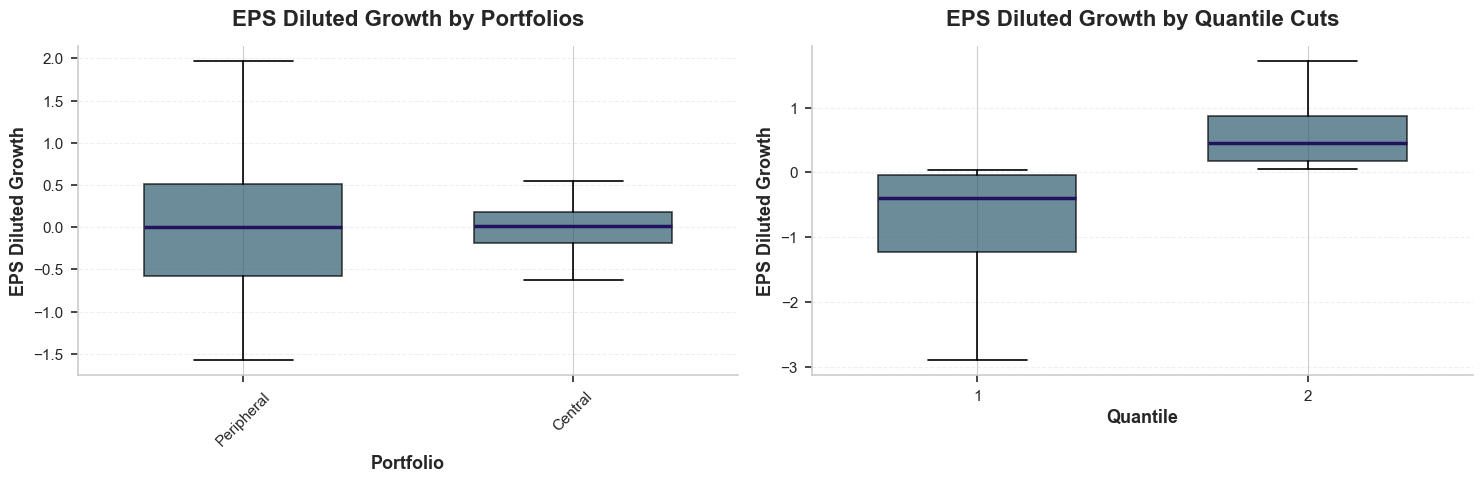

In [85]:
plot_metric_boxplots(
    df=final_df,
    metric=f"epsdg_{year}",
    log_scale=False,
    metric_name="EPS Diluted Growth"
)

### Beta

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


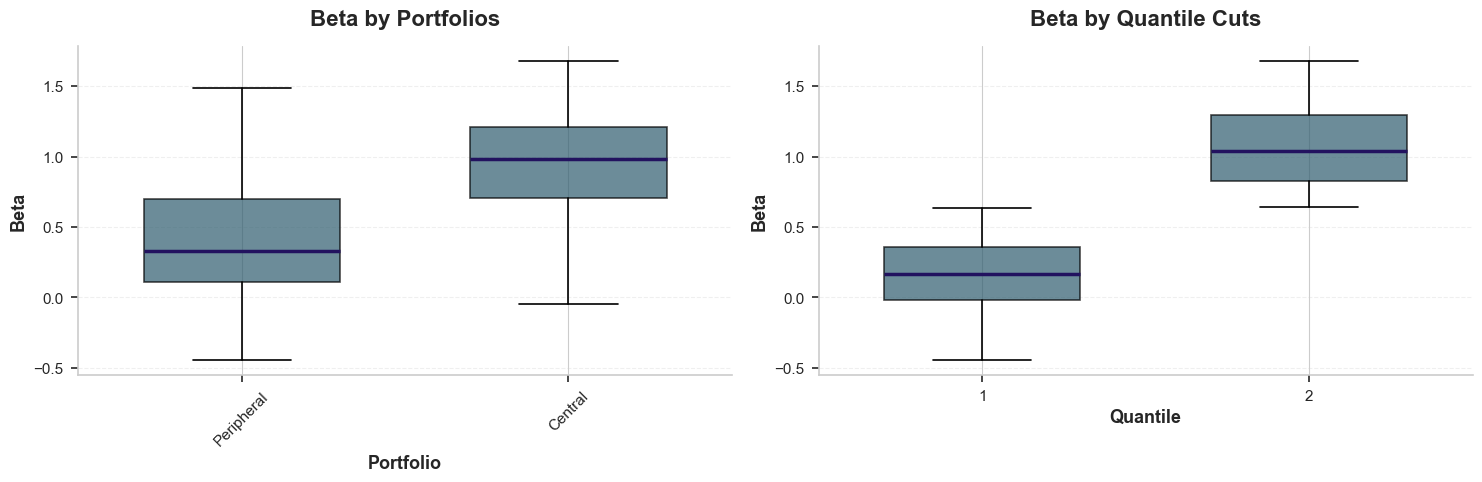

In [86]:
plot_metric_boxplots(
    df=final_df,
    metric=f"beta_{year}",
    log_scale=False,
    metric_name="Beta"
)

### Momentum 12 months

C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax[0].boxplot(
C:\Users\groque\AppData\Local\Temp\ipykernel_6384\4294136442.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax[1].boxplot(


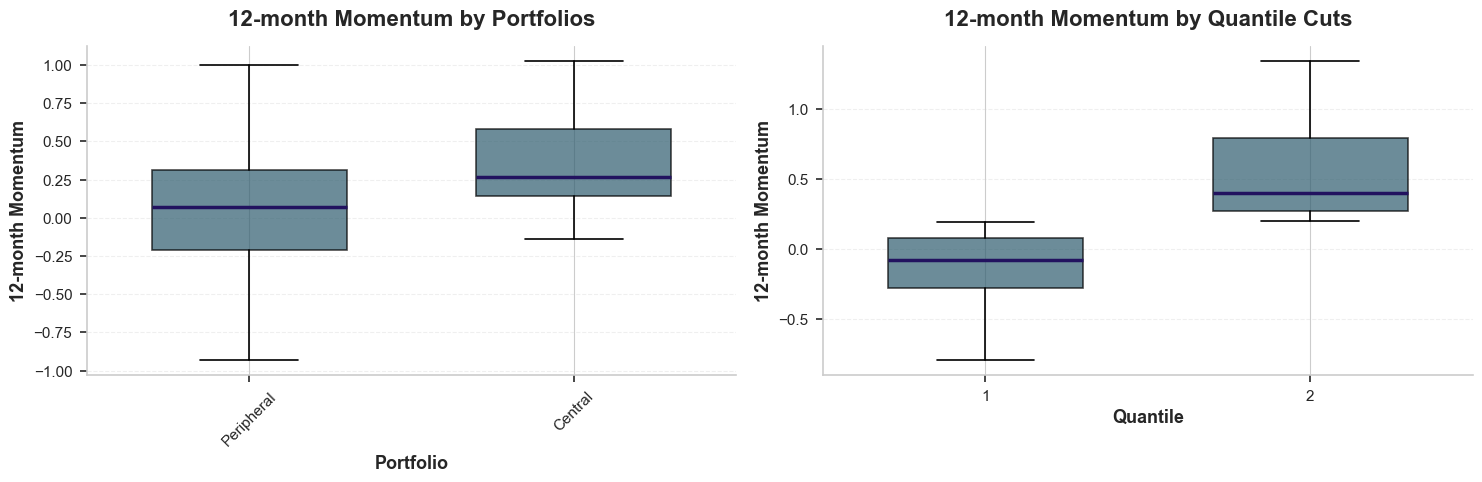

In [87]:
plot_metric_boxplots(
    df=final_df,
    metric=f"momentum12mo_{year}",
    log_scale=False,
    metric_name="12-month Momentum"
)